# TP 3 — Q-Learning, SARSA et comparaison
## Environnement : `Blackjack-v1`

### Objectif pédagogique
Ce TP permet de travailler sur un environnement plus stochastique et moins visuel.

On va comparer deux méthodes classiques :

- Q-Learning ;
- SARSA.

L’objectif est de comprendre la différence entre :

- apprentissage off-policy ;
- apprentissage on-policy ;
- exploration ;
- exploitation ;
- stratégie d’apprentissage.

In [ ]:
# !pip install gymnasium numpy matplotlib

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print("Bibliothèques importées.")

Bibliothèques importées.


## 1. Création de l’environnement Blackjack-v1

Dans Blackjack, l’agent joue contre le croupier.

Actions possibles :

- `0` : stick — ne plus tirer de carte ;
- `1` : hit — tirer une nouvelle carte.

L’état est représenté par un triplet :

`(somme du joueur, carte visible du croupier, as utilisable)`.

In [ ]:
env = gym.make("Blackjack-v1", sab=True)

state, info = env.reset()

print("État initial :", state)
print("Nombre d'actions :", env.action_space.n)
print("0 = Stick")
print("1 = Hit")

État initial : (12, 10, 0)
Nombre d'actions : 2
0 = Stick
1 = Hit


## 2. Politique epsilon-greedy

La politique epsilon-greedy permet d’équilibrer :

- exploration : essayer des actions nouvelles ;
- exploitation : choisir la meilleure action connue.

Avec une probabilité `epsilon`, l’agent explore.
Sinon, il choisit l’action ayant la meilleure valeur Q.

In [ ]:
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q[state])

## 3. Implémentation du Q-Learning

Le Q-Learning est une méthode off-policy.

La mise à jour utilise la meilleure action possible dans le nouvel état, même si cette action n’est pas forcément celle réellement choisie.

In [ ]:
def train_q_learning(env, n_episodes=50000, alpha=0.1, gamma=0.99, epsilon=0.1):
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards = []

    for episode in range(n_episodes):
        state, info = env.reset()
        total_reward = 0

        terminated = False
        truncated = False

        while not terminated and not truncated:
            action = epsilon_greedy_policy(Q, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, info = env.step(action)

            best_next_action = np.argmax(Q[next_state])

            Q[state][action] = Q[state][action] + alpha * (
                reward + gamma * Q[next_state][best_next_action] - Q[state][action]
            )

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return Q, rewards

## 4. Implémentation de SARSA

SARSA est une méthode on-policy.

La mise à jour utilise l’action réellement choisie dans le nouvel état selon la politique courante.

In [ ]:
def train_sarsa(env, n_episodes=50000, alpha=0.1, gamma=0.99, epsilon=0.1):
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards = []

    for episode in range(n_episodes):
        state, info = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon, n_actions)
        total_reward = 0

        terminated = False
        truncated = False

        while not terminated and not truncated:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon, n_actions)

            Q[state][action] = Q[state][action] + alpha * (
                reward + gamma * Q[next_state][next_action] - Q[state][action]
            )

            state = next_state
            action = next_action
            total_reward += reward

        rewards.append(total_reward)

    return Q, rewards

## 5. Entraînement des deux agents

In [ ]:
Q_qlearning, rewards_qlearning = train_q_learning(env)
Q_sarsa, rewards_sarsa = train_sarsa(env)

print("Entraînement terminé.")
print("Récompense moyenne Q-Learning :", np.mean(rewards_qlearning[-1000:]))
print("Récompense moyenne SARSA :", np.mean(rewards_sarsa[-1000:]))

Entraînement terminé.
Récompense moyenne Q-Learning : -0.142
Récompense moyenne SARSA : -0.153


## 6. Moyenne glissante des récompenses

Pour mieux visualiser l’évolution de l’apprentissage, on calcule une moyenne glissante.

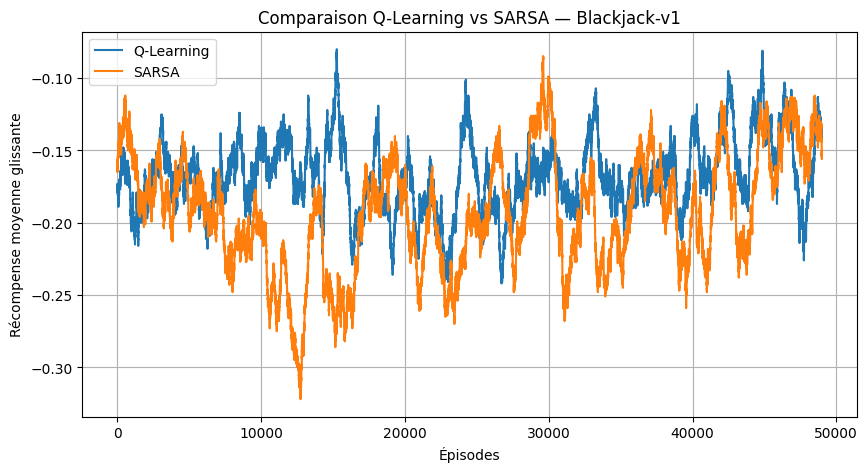

In [ ]:
def moving_average(values, window=1000):
    return np.convolve(values, np.ones(window)/window, mode='valid')

ma_qlearning = moving_average(rewards_qlearning)
ma_sarsa = moving_average(rewards_sarsa)

plt.figure(figsize=(10,5))
plt.plot(ma_qlearning, label="Q-Learning")
plt.plot(ma_sarsa, label="SARSA")
plt.xlabel("Épisodes")
plt.ylabel("Récompense moyenne glissante")
plt.title("Comparaison Q-Learning vs SARSA — Blackjack-v1")
plt.legend()
plt.grid(True)
plt.show()

## 7. Évaluation d’une politique apprise

On évalue maintenant une politique sans exploration : l’agent choisit toujours la meilleure action connue.

In [ ]:
def evaluate_policy(env, Q, n_episodes=10000):
    rewards = []

    for episode in range(n_episodes):
        state, info = env.reset()
        total_reward = 0
        terminated = False
        truncated = False

        while not terminated and not truncated:
            action = np.argmax(Q[state])
            state, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

        rewards.append(total_reward)

    return np.mean(rewards), rewards

mean_q, eval_rewards_q = evaluate_policy(env, Q_qlearning)
mean_s, eval_rewards_s = evaluate_policy(env, Q_sarsa)

print("Performance moyenne Q-Learning :", mean_q)
print("Performance moyenne SARSA :", mean_s)

Performance moyenne Q-Learning : -0.1392
Performance moyenne SARSA : -0.1092


## 8. Comparaison finale sous forme d’histogramme

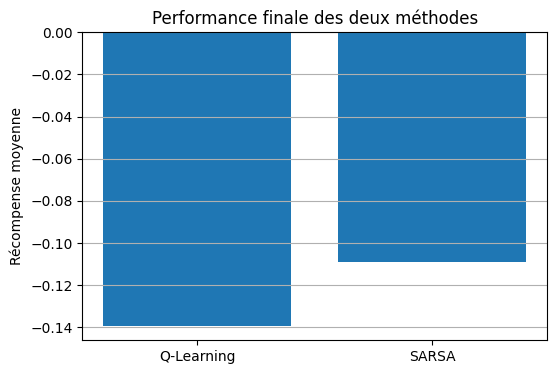

In [ ]:
labels = ["Q-Learning", "SARSA"]
means = [mean_q, mean_s]

plt.figure(figsize=(6,4))
plt.bar(labels, means)
plt.ylabel("Récompense moyenne")
plt.title("Performance finale des deux méthodes")
plt.grid(axis="y")
plt.show()

## 9. Extraction d’une politique simple

Pour quelques états possibles, on affiche l’action recommandée par l’agent.

In [ ]:
example_states = [
    (12, 1, False),
    (16, 10, False),
    (18, 6, False),
    (20, 10, False),
    (13, 2, True),
    (18, 9, True)
]

action_names = {0: "Stick", 1: "Hit"}

print("Politique apprise par Q-Learning :")
for s in example_states:
    action = np.argmax(Q_qlearning[s])
    print(s, "=>", action_names[action])

print("\nPolitique apprise par SARSA :")
for s in example_states:
    action = np.argmax(Q_sarsa[s])
    print(s, "=>", action_names[action])

Politique apprise par Q-Learning :
(12, 1, False) => Hit
(16, 10, False) => Stick
(18, 6, False) => Stick
(20, 10, False) => Stick
(13, 2, True) => Hit
(18, 9, True) => Hit

Politique apprise par SARSA :
(12, 1, False) => Hit
(16, 10, False) => Hit
(18, 6, False) => Stick
(20, 10, False) => Stick
(13, 2, True) => Hit
(18, 9, True) => Hit


## 10. Correction / Interprétation

Le Q-Learning et SARSA apprennent tous les deux une stratégie à partir de l’expérience.

### Différence principale

Q-Learning :

- méthode off-policy ;
- utilise la meilleure action possible dans l’état suivant ;
- peut être plus optimiste.

SARSA :

- méthode on-policy ;
- utilise l’action réellement choisie par la politique ;
- tient compte de l’exploration dans son apprentissage.

### Conclusion du TP 4

Ce TP a permis de comprendre :

- la représentation d’un état non visuel ;
- la Q-table avec des états sous forme de tuples ;
- l’exploration epsilon-greedy ;
- le Q-Learning ;
- SARSA ;
- la comparaison expérimentale entre deux algorithmes RL.